# Vertiefung pandas - Performance-Themen

In dieser Woche werden wir uns mit der Performance von Pandas befassen und untersuchen, wie wir unseren Code optimieren können, um die Verarbeitung grosser Datenmengen zu beschleunigen und den Speicherbedarf zu reduzieren. Wir werden uns auch mit einigen der Best-Practices bei der Verwendung von Pandas befassen, um die Leistung und Effizienz zu maximieren.

Zunächst werden wir uns einige Gründe anschauen, warum Pandas bei der Verarbeitung grosser Datensätze langsam sein kann. Dann werden wir einige Techniken und Funktionen von Pandas betrachten, die zur Optimierung der Performance beitragen können, wie beispielsweise das Arbeiten vektorbasierten Methoden im Vergleich zu der apply()-Funktion oder den foor-Loops.

Darüber hinaus werden wir uns mit dem Speicherbedarf von Pandas befassen und untersuchen, wie dieser reduziert werden kann. Wir werden uns mit der Verwendung von komprimierten Datenformaten und der Verwendung von Datentypen mit geringerem Speicherbedarf befassen.

Insgesamt ist es wichtig zu verstehen, wie man Pandas optimal nutzen kann, um die Performance und Effizienz bei der Verarbeitung grosser Datensätze zu maximieren. Mit den richtigen Techniken und Best Practices können wir die Geschwindigkeit und den Speicherbedarf von Pandas reduzieren und effektiv grosse Datenmengen analysieren.

Aus zeitlichen Gründen können wir leider auf die Verwendung von Dask oder ähnliche Tools nicht eingehen. Diese Tools wurden entwickelt, um die Leistung von Pandas zu verbessern, indem sie die Verarbeitung auf mehrere Prozessoren oder Computer verteilen. Wenn du mehr über diese Tools erfahren möchtest, kannst du die folgenden Ressourcen ansehen: [Dask](https://dask.org/)

### Gründe, warum Pandas bei der Verarbeitung grosser Datensätze langsam sein kann:

- Verwendung von Schleifen: Schleifen sind in Pandas in der Regel langsamer als Vektoroperationen, die auf die gesamte Datensatzspalte angewendet werden können. Wenn Schleifen verwendet werden müssen, sollten sie vermieden werden, indem man iterrows oder itertuples verwendet.

- Verwendung von unangemessenen Datentypen: Wenn falsche Datentypen für die Spalten in einem DataFrame verwendet werden, kann dies die Performance von Pandas beeinträchtigen. In diesem Fall sollten geeignete Datentypen wie int, float oder bool verwendet werden, um die Verarbeitungszeit zu reduzieren.

- Komplexe Transformationen: Wenn komplexe Transformationen auf grosse Datensätze angewendet werden, kann dies die Performance von Pandas beeinträchtigen. In diesem Fall können Techniken wie Chunking oder Parallelisierung verwendet werden, um die Verarbeitungszeit zu reduzieren. (Können wir nicht behandeln, da wir nicht auf Dask eingehen)

- Zu viele Spalten oder Zeilen: Wenn die Anzahl der Spalten oder Zeilen in einem DataFrame zu gross wird, kann dies die Performance von Pandas beeinträchtigen. In diesem Fall kann es sinnvoll sein, nur die benötigten Spalten zu wählen oder den DataFrame in kleinere Teile aufzuteilen, um die Verarbeitungszeit zu reduzieren. 

- usw.

### Verwendung von Schleifen und dessen Auswirkungen auf die Performance

In [1]:
import pandas as pd
import numpy as np

Erstellen wir zunächst eine DataFrame mit n Zeilen. 
Die Daten sollen zufällig generiert werden und die folgenden Spalten enthalten: 

- Alter der Person
- Geschlecht der Person
- Zeit im Bett
- Ist Raucher
- Anteil der Zeit im Bett, in der die Person schläft
- Lieblingsessen der Person
- Essen, das die Person nicht mag

In [2]:
rng = np.random.default_rng(12345678)
size_n = 10_000

df = pd.DataFrame()

df["age"] = rng.integers(1, 100, size=size_n)
df["gender"] = rng.choice(["female", "male"], size=size_n)
df["is_smoker"] = rng.choice(["yes", "no"], size=size_n)
df["time_in_bed"] = rng.integers(0, 11, size=size_n)
df["pct_sleeping"] = rng.random(size=size_n)
df["favorite_food"] = rng.choice(["pizza", "pasta", "burger", "salad", "soup"], size_n)
df["hate_food"] = rng.choice(["broccoli", "fennel", "oliven", "eggs"], size_n)

df.head()

,age,gender,is_smoker,time_in_bed,pct_sleeping,favorite_food,hate_food
0,96,female,no,10,0.376899,salad,eggs
1,95,male,no,10,0.836227,soup,fennel
2,47,male,yes,8,0.311002,soup,eggs
3,87,female,no,1,0.645765,pizza,broccoli
4,29,male,yes,5,0.946127,pasta,fennel


In [3]:
df.describe(include="all")

,age,gender,is_smoker,time_in_bed,pct_sleeping,favorite_food,hate_food
count,10000.000000,10000,10000,10000.000000,10000.000000,10000,10000
unique,NaN,2,2,NaN,NaN,5,4
top,NaN,male,yes,NaN,NaN,pasta,eggs
freq,NaN,5102,5038,NaN,NaN,2086,2557
mean,50.046700,NaN,NaN,4.958500,0.498612,NaN,NaN
std,28.558524,NaN,NaN,3.152994,0.289032,NaN,NaN
min,1.000000,NaN,NaN,0.000000,0.000049,NaN,NaN
25%,25.000000,NaN,NaN,2.000000,0.248190,NaN,NaN
50%,50.000000,NaN,NaN,5.000000,0.498859,NaN,NaN
75%,75.000000,NaN,NaN,8.000000,0.747966,NaN,NaN


In [4]:
def get_data(size_n=10_000):
    df = pd.DataFrame()

    df["age"] = rng.integers(1, 100, size=size_n)
    df["gender"] = rng.choice(["female", "male"], size=size_n)
    df["is_smoker"] = rng.choice(["yes", "no"], size=size_n)
    df["time_in_bed"] = rng.integers(0, 11, size=size_n)
    df["pct_sleeping"] = rng.random(size=size_n)
    df["favorite_food"] = rng.choice(
        ["pizza", "pasta", "burger", "salad", "soup"], size_n
    )
    df["hate_food"] = rng.choice(["broccoli", "fennel", "oliven", "eggs"], size_n)

    return df

Stellen wir uns nun die folgende Aufgabe vor: 
- Wir belohnen die Person die länger als 5 Stunden im Bett liegen und mehr als 50% der Zeit schlafen mit ihrem Lieblingsessen.
- sonst bestrafen wir die Person mit einem Essen, das sie nicht mag.
- Wenn die Person älter als 80 Jahre alt ist, bekommt die Person sowieso das Lieblingsessen. 

In [5]:
def reward_cal(row):
    if row["age"] >= 80:
        return row["favorite_food"]
    if (row["time_in_bed"] >= 5) & (row["pct_sleeping"] >= 0.5):
        return row["favorite_food"]
    else:
        return row["hate_food"]

#### Methode 1 - Loopen über die Zeilen und Anwendung der Funktion auf jede Zeile:

In [6]:
df = get_data()

In [7]:
for index, row in df.iterrows():
    df.loc[index, "reward"] = reward_cal(row)

In [8]:
df.head()

,age,gender,is_smoker,time_in_bed,pct_sleeping,favorite_food,hate_food,reward
0,69,female,no,2,0.952777,soup,eggs,eggs
1,68,male,yes,5,0.558435,burger,oliven,burger
2,41,female,no,7,0.430820,pizza,oliven,oliven
3,86,male,no,5,0.897321,pasta,fennel,pasta
4,78,male,no,5,0.720376,pasta,eggs,pasta


Messung der Zeit, die für die Ausführung der Funktion mit einem for-Loop benötigt wird

In [9]:
%%timeit
for index, row in df.iterrows():
    df.loc[index, "reward"] = reward_cal(row)

19.1 s ± 4.15 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
df_100 = get_data(100_000)

In [11]:
%%timeit
for index, row in df_100.iterrows():
    df_100.loc[index, "reward"] = reward_cal(row)

The slowest run took 4.40 times longer than the fastest. This could mean that an intermediate result is being cached.
1min 12s ± 42.9 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


#### Methode 2 - apply()-Funktion:

In [12]:
%%timeit
df["reward"] = df.apply(reward_cal, axis=1)

293 ms ± 161 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [13]:
%%timeit
df_100["reward"] = df_100.apply(reward_cal, axis=1)

1.45 s ± 147 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


#### Methode 3 - Vectorized:

In [14]:
((df["pct_sleeping"] >= 0.5) & (df["time_in_bed"] >= 5) | (df["age"] >= 80))

0       False
1        True
2       False
3        True
4        True
        ...  
9995     True
9996     True
9997     True
9998    False
9999     True
Length: 10000, dtype: bool

In [15]:
%%timeit
df['reward'] = df['hate_food']
df.loc[((df['pct_sleeping'] >= 0.5) & (df['time_in_bed'] >= 5)
        | (df['age'] >= 80)), 'reward'] = df['favorite_food']

2.46 ms ± 589 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [16]:
df

,age,gender,is_smoker,time_in_bed,pct_sleeping,favorite_food,hate_food,reward
0,69,female,no,2,0.952777,soup,eggs,eggs
1,68,male,yes,5,0.558435,burger,oliven,burger
2,41,female,no,7,0.430820,pizza,oliven,oliven
3,86,male,no,5,0.897321,pasta,fennel,pasta
4,78,male,no,5,0.720376,pasta,eggs,pasta
...,...,...,...,...,...,...,...,...
9995,87,male,no,5,0.210753,burger,eggs,burger
9996,41,female,yes,8,0.761616,burger,eggs,burger
9997,90,female,yes,3,0.733793,pasta,eggs,pasta
9998,46,male,yes,4,0.523204,soup,eggs,eggs


In [17]:
%%timeit
df_100['reward'] = df_100['hate_food']
df_100.loc[((df['pct_sleeping'] >= 0.5) & (df_100['time_in_bed'] >= 5)
        | (df['age'] >= 80)), 'reward'] = df_100['favorite_food']

157 ms ± 44.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


#### Plot der Laufzeit für die drei Methoden:

In [18]:
results = pd.DataFrame(
    [
        ["loop", 1340, 10000],
        ["apply", 109, 10000],
        ["vectoried", 2, 10000],
        ["loop", 11500, 100000],
        ["apply", 1160, 100000],
        ["vectoried", 112, 100000],
    ],
    columns=["type", "time[ms]", "size"],
)

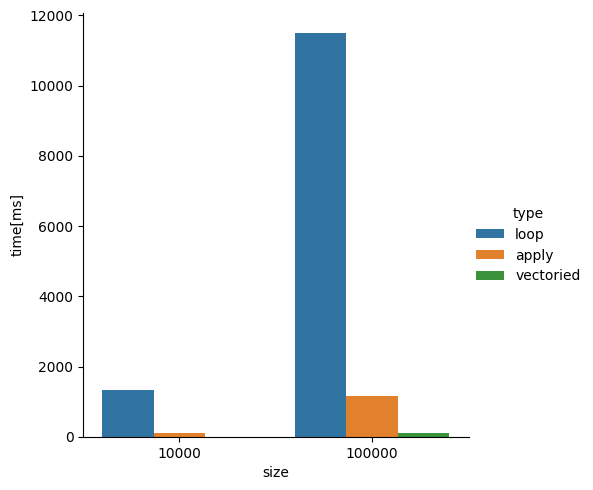

In [19]:
import seaborn as sns

sns.catplot(data=results, x="size", y="time[ms]", hue="type", kind="bar")

#### Zusammenfassung Performance
- for-Loops:
Schleifen sind die grundlegendste Möglichkeit, Operationen auf Daten in Pandas durchzuführen. Sie bieten maximale Flexibilität, da sie komplexe Transformationen und Bedingungen auf den Daten innerhalb der Schleife durchführen können. Allerdings sind sie in der Regel langsam und ineffizient, insbesondere bei der Verarbeitung grosser Datensätze. Daher sollten Schleifen nur dann verwendet werden, wenn andere Optionen nicht verfügbar sind.

- Methode apply():
Apply() ist eine Methode, die auf DataFrame-Objekte in Pandas angewendet werden kann. Sie ist schneller als Schleifen, da sie auf eine optimierte, vektorisierte Art und Weise implementiert ist. Apply() ist einfach zu verwenden und bietet eine höhere Lesbarkeit und Wartbarkeit des Codes. Ausserdem unterstützt sie die Parallelisierung, was die Verarbeitungsgeschwindigkeit von grossen Datensätzen erhöhen kann. Allerdings kann apply() bei komplexeren Operationen oder Bedingungen weniger flexibel sein als Schleifen.

- Vektorisierte Operationen:
Vektorisierte Operationen sind eine der schnellsten Möglichkeiten, um Operationen auf Daten in Pandas durchzuführen. Sie sind in der Regel schneller als Schleifen oder apply(), da sie auf C implementiert sind und so die Ausführungsgeschwindigkeit erhöhen können. Vektorisierte Operationen bieten jedoch weniger Flexibilität als Schleifen oder apply() und können schwieriger zu implementieren sein.


### Effiziente Nutzung des Arbeitsspeichers in Pandas

In [20]:
df_1000 = get_data(1_000_000)

In [21]:
df_1000.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   age            1000000 non-null  int64  
 1   gender         1000000 non-null  str    
 2   is_smoker      1000000 non-null  str    
 3   time_in_bed    1000000 non-null  int64  
 4   pct_sleeping   1000000 non-null  float64
 5   favorite_food  1000000 non-null  str    
 6   hate_food      1000000 non-null  str    
dtypes: float64(1), int64(2), str(4)
memory usage: 227.5 MB


In [22]:
df_1000["gender"].memory_usage(deep=True)

54001040

In [23]:
df_1000.memory_usage(deep=True)

Index                 132
age               8000000
gender           54000908
is_smoker        51499272
time_in_bed       8000000
pct_sleeping      8000000
favorite_food    54000141
hate_food        54999420
dtype: int64

In [24]:
df_1000.head()

,age,gender,is_smoker,time_in_bed,pct_sleeping,favorite_food,hate_food
0,35,female,no,9,0.600820,pasta,eggs
1,81,female,no,3,0.145307,burger,eggs
2,47,female,no,5,0.348270,burger,oliven
3,31,female,no,6,0.162043,soup,eggs
4,82,female,yes,10,0.910873,pizza,eggs


In [25]:
df_1000["gender"] = df_1000["gender"].astype("category")
df_1000.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype   
---  ------         --------------    -----   
 0   age            1000000 non-null  int64   
 1   gender         1000000 non-null  category
 2   is_smoker      1000000 non-null  str     
 3   time_in_bed    1000000 non-null  int64   
 4   pct_sleeping   1000000 non-null  float64 
 5   favorite_food  1000000 non-null  str     
 6   hate_food      1000000 non-null  str     
dtypes: category(1), float64(1), int64(2), str(3)
memory usage: 176.9 MB


In [26]:
df_1000

,age,gender,is_smoker,time_in_bed,pct_sleeping,favorite_food,hate_food
0,35,female,no,9,0.600820,pasta,eggs
1,81,female,no,3,0.145307,burger,eggs
2,47,female,no,5,0.348270,burger,oliven
3,31,female,no,6,0.162043,soup,eggs
4,82,female,yes,10,0.910873,pizza,eggs
...,...,...,...,...,...,...,...
999995,5,female,no,9,0.894240,pasta,eggs
999996,89,male,yes,8,0.980935,burger,oliven
999997,10,female,yes,10,0.660784,salad,eggs
999998,42,male,no,2,0.700252,pizza,eggs


In [27]:
df_1000["is_smoker"] = (
    df_1000["is_smoker"].map({"yes": True, "no": False}).astype("bool")
)
df_1000.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype   
---  ------         --------------    -----   
 0   age            1000000 non-null  int64   
 1   gender         1000000 non-null  category
 2   is_smoker      1000000 non-null  bool    
 3   time_in_bed    1000000 non-null  int64   
 4   pct_sleeping   1000000 non-null  float64 
 5   favorite_food  1000000 non-null  str     
 6   hate_food      1000000 non-null  str     
dtypes: bool(1), category(1), float64(1), int64(2), str(2)
memory usage: 128.7 MB


In [28]:
df_1000["age"].min()

np.int64(1)

In [29]:
df_1000["age"].max()

np.int64(99)

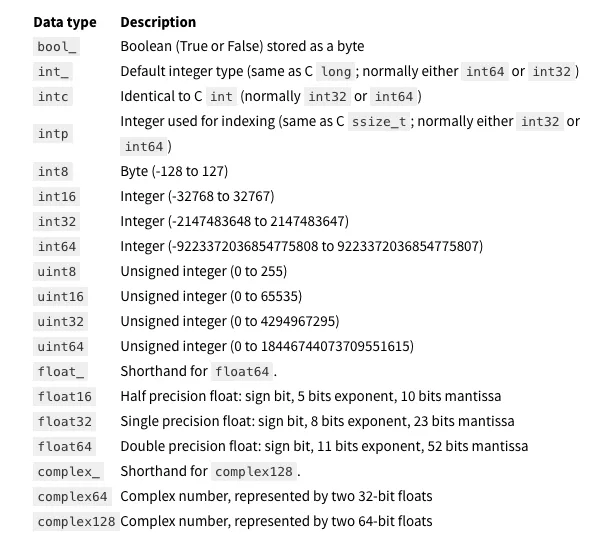

In [30]:
df_1000["age"] = df_1000["age"].astype("uint8")
df_1000.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype   
---  ------         --------------    -----   
 0   age            1000000 non-null  uint8   
 1   gender         1000000 non-null  category
 2   is_smoker      1000000 non-null  bool    
 3   time_in_bed    1000000 non-null  int64   
 4   pct_sleeping   1000000 non-null  float64 
 5   favorite_food  1000000 non-null  str     
 6   hate_food      1000000 non-null  str     
dtypes: bool(1), category(1), float64(1), int64(1), str(2), uint8(1)
memory usage: 122.1 MB


In [31]:
def set_dtypes(df):
    df["gender"] = df["gender"].astype("category")
    df["is_smoker"] = df["is_smoker"].map({"yes": True, "no": False}).astype("bool")
    df["age"] = df["age"].astype("uint8")
    df["time_in_bed"] = df["time_in_bed"].astype("uint8")
    df["favorite_food"] = df["favorite_food"].astype("category")
    df["hate_food"] = df["hate_food"].astype("category")
    df["pct_sleeping"] = df["pct_sleeping"].astype("float16")
    return df

In [32]:
df_1000 = get_data(1_000_000)
df_1000.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   age            1000000 non-null  int64  
 1   gender         1000000 non-null  str    
 2   is_smoker      1000000 non-null  str    
 3   time_in_bed    1000000 non-null  int64  
 4   pct_sleeping   1000000 non-null  float64
 5   favorite_food  1000000 non-null  str    
 6   hate_food      1000000 non-null  str    
dtypes: float64(1), int64(2), str(4)
memory usage: 227.5 MB


In [33]:
df_1000 = get_data(1_000_000)
df_1000 = set_dtypes(df_1000)
df_1000.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype   
---  ------         --------------    -----   
 0   age            1000000 non-null  uint8   
 1   gender         1000000 non-null  category
 2   is_smoker      1000000 non-null  bool    
 3   time_in_bed    1000000 non-null  uint8   
 4   pct_sleeping   1000000 non-null  float16 
 5   favorite_food  1000000 non-null  category
 6   hate_food      1000000 non-null  category
dtypes: bool(1), category(3), float16(1), uint8(2)
memory usage: 7.6 MB


Wichtig ist es nicht erst dann über die Speichernutzung nachzudenken, wenn der Arbeitsspeicher voll ist. Sondern, die Speichernutzung von Anfang an zu optimieren, um die Verarbeitungsgeschwindigkeit zu erhöhen und die Leistung von Pandas zu verbessern.
Dazu können wir bereits beim Einlesen der Daten die Datentypen der Spalten definieren.

In [34]:
df_1000.to_csv("data.csv", index=False)

In [35]:
df_1000 = pd.read_csv("data.csv")
df_1000.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   age            1000000 non-null  int64  
 1   gender         1000000 non-null  str    
 2   is_smoker      1000000 non-null  bool   
 3   time_in_bed    1000000 non-null  int64  
 4   pct_sleeping   1000000 non-null  float64
 5   favorite_food  1000000 non-null  str    
 6   hate_food      1000000 non-null  str    
dtypes: bool(1), float64(1), int64(2), str(3)
memory usage: 179.3 MB


In [36]:
df_1000 = pd.read_csv(
    "data.csv",
    dtype={
        "age": "uint8",
        "gender": "category",
        "is_smoker": "bool",
        "time_in_bed": "uint8",
        "pct_sleeping": "float16",
        "favorite_food": "category",
        "hate_food": "category",
    },
)
df_1000.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype   
---  ------         --------------    -----   
 0   age            1000000 non-null  uint8   
 1   gender         1000000 non-null  category
 2   is_smoker      1000000 non-null  bool    
 3   time_in_bed    1000000 non-null  uint8   
 4   pct_sleeping   1000000 non-null  float16 
 5   favorite_food  1000000 non-null  category
 6   hate_food      1000000 non-null  category
dtypes: bool(1), category(3), float16(1), uint8(2)
memory usage: 7.6 MB
